# CRVSE Phase B - Ensemble rPPG - CRVSEInceptionNet 1D (Round 2) part 2 - multichannel (3ch)

### What this notebook does

Trains CRVSEInceptionNet on ensemble rPPG signals (POS + CHROM + GREEN)using multichannel approach

Study:`multichannel` - stacked [POS, CHROM, GREEN] as independent input channels. Model learns implicit SQI weighting.

In [1]:
import h5py, torch, os, optuna, json
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from scipy import stats
from scipy.signal import resample
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict, Counter
from tqdm import tqdm
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

#  Paths 
H5_PATHS = {
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/mcd_rppg_ensemble.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_rppg_ensemble.h5",
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ubfc_phys_ensemble.h5",
    "ecg_fitness": "/kaggle/input/datasets/cezarytubacki/rppg-ensemble/rPPG ensemble/ecg_fitness_ensemble.h5"
}

# SQI gates per dataset 
# Thresholds calibrated during preprocessing (see NB06/NB07/NB08).
# MCD-rPPG 0.10 : recalibrated (ensemble scale differs from POS-only)
# UBFC-rPPG 0.07: original threshold, clean lab conditions
# UBFC-Phys 0.05: lowered - 35fps + 1024x1024 + stress tasks lower spectral SQI
DATASET_SQI_THRESHOLDS = {
    "mcd_rppg"  : 0.10,
    "ubfc_rppg" : 0.07,
    "ubfc_phys" : 0.05,
    "ecg_fitness" : 0.07
}

# Fixed config 
MODEL_NAME = "CRVSEInceptionNet_Ensemble"
INPUT_MODE = "multichannel"
IN_CHANNELS = 3 # stacked [POS, CHROM, GREEN]
STUDY_NAME = "inception_b_ens_multi"

HR_MIN = 40.0
HR_MAX = 180.0
MAX_NAN_FRAC = 0.10
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config  
N_TRIALS = 30
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5  

print(f"Device : {DEVICE}")
print(f"Input mode : {INPUT_MODE}  ({IN_CHANNELS} channels)")
print(f"Trials : {N_TRIALS} | Max epochs/trial : {N_EPOCHS}")
print(f"Datasets : {list(H5_PATHS.keys())}")

Device : cuda
Input mode : multichannel  (3 channels)
Trials : 30 | Max epochs/trial : 50
Datasets : ['mcd_rppg', 'ubfc_rppg', 'ubfc_phys', 'ecg_fitness']


## 2. Window Extractor

In [2]:
def extract_windows(signals: dict, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int,
                    target_frames: int, max_nan_frac: float, hr_min: float, hr_max: float) -> list:
    """
    Extract sliding windows from one recording.
    Returns list of dicts: pos_win, chrom_win, green_win, ensemble_win (target_frames,), hr_label.
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(hr_cont)
    results = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames
        hr_win = hr_cont[start:end]

        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue

        hr_label = float(np.nanmean(hr_win))
        if not (hr_min <= hr_label <= hr_max):
            continue

        win_dict = {}
        skip = False

        for key in ("pos", "chrom", "green", "ensemble"):
            sig_win = signals[key][start:end]

            if np.any(np.isnan(sig_win)):
                skip = True
                break

            if len(sig_win) != target_frames:
                sig_win = resample(sig_win, target_frames).astype(np.float32)

            std = sig_win.std()
            if std < 1e-6:
                skip = True
                break

            sig_win = ((sig_win - sig_win.mean()) / std).astype(np.float32)
            win_dict[f"{key}_win"] = sig_win

        if skip:
            continue

        win_dict["hr_label"] = hr_label
        results.append(win_dict)

    return results

## 3. Index Builder

Reads all HDF5 files once, builds flat window list with all four signal channels. SQI gating applied per dataset.

In [3]:
def build_index(h5_paths: dict, sqi_thresholds: dict, window_sec: int, stride_sec: int, target_frames: int,
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Builds flat window index from all ensemble HDF5 files.
    SQI gate per dataset. Returns (samples, sorted subject_keys).
    """
    samples = []
    subject_keys = set()
    skipped_sqi = 0

    for dataset_name, path in h5_paths.items():
        if not os.path.exists(path):
            print(f"[WARN] Not found, skipping: {path}")
            continue

        sqi_gate = sqi_thresholds.get(dataset_name, 0.07)

        with h5py.File(path, "r") as file:
            subjects = file["subjects"]
            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]
                    sqi_ens = float(rec.attrs.get("sqi_ensemble", 1.0))
                    if sqi_ens < sqi_gate:
                        skipped_sqi += 1
                        continue

                    fps = float(rec.attrs["fps"])
                    hr_cont = rec["hr_continuous"][:]
                    signals = {
                        "pos": rec["rppg_pos"][:],
                        "chrom": rec["rppg_chrom"][:],
                        "green": rec["rppg_green"][:],
                        "ensemble": rec["rppg_ensemble"][:],
                    }
                    wins = extract_windows(signals, hr_cont, fps, window_sec, stride_sec,
                                           target_frames, max_nan_frac, hr_min, hr_max)
                    for w in wins:
                        w["subject_key"] = subj_key
                        w["dataset"] = dataset_name
                        samples.append(w)

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    print(f"Recordings skipped (SQI) : {skipped_sqi}")
    ds_counts = Counter(s["dataset"] for s in samples)
    print("\nPer-dataset window counts:")
    for ds, n in sorted(ds_counts.items()):
        print(f"{ds:<15} : {n:>6} windows")

    return samples, sorted(subject_keys)

## 4. Subject-Level Train/Val/Test Split

In [4]:
def subject_split(subject_keys: list, train_frac: float = 0.7, val_frac: float = 0.15, seed: int = 42) -> tuple:
    """Subject-level stratified split. test_frac = 1 - train_frac - val_frac."""
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys = set(keys[:n_train])
    val_keys = set(keys[n_train : n_train + n_val])
    test_keys = set(keys[n_train + n_val:])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset Class

`multichannel -> (3, 250)`

In [5]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase B ensemble rPPG -> HR estimation.
    
    input_mode:
        `ensemble_only` -> tensor (1, 240) pre-fused quality-weighted ensemble
        `multichannel` -> tensor (3, 240) stacked [POS, CHROM, GREEN]
    """
    def __init__(self, samples: list, subject_set: set, input_mode: str = "multichannel") -> None:
        self.input_mode = input_mode
        self.items = [s for s in samples if s["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows  (mode={input_mode})")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple:
        item = self.items[idx]
        if self.input_mode == "ensemble_only":
            signal = torch.tensor(item["ensemble_win"], dtype=torch.float32).unsqueeze(0)
        else:
            signal = torch.stack([
                torch.tensor(item["pos_win"],   dtype=torch.float32),
                torch.tensor(item["chrom_win"], dtype=torch.float32),
                torch.tensor(item["green_win"], dtype=torch.float32),
            ])
        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label

## 6. Model Architecture

In [6]:
class InceptionBlock1d(nn.Module):
    """
    Parallel multi-scale convolutions capturing rPPG features at:
      short (kernel=3)  -> morphology
      medium (kernel=7) -> beat shape
      long (kernel=15)  -> rhythm / rate
    Plus a MaxPool branch for amplitude peaks.
    Output channels = out_channels * 4.
    """
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.2) -> None:
        super().__init__()
        self.branch_short  = self._branch(in_channels, out_channels, kernel=3)
        self.branch_medium = self._branch(in_channels, out_channels, kernel=7)
        self.branch_long = self._branch(in_channels, out_channels, kernel=15)
        self.branch_pool = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
        )
        self.dropout = nn.Dropout(dropout)

    def _branch(self, in_ch: int, out_ch: int, kernel: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = torch.cat([
            self.branch_short(x),
            self.branch_medium(x),
            self.branch_long(x),
            self.branch_pool(x),
        ], dim=1)
        return self.dropout(out)


class CRVSEInceptionNet1D(nn.Module):
    """
    Stacked Inception blocks for rPPG -> HR regression.
    head_dim = branch_channels * 2  (scales automatically).
    """
    def __init__(
        self,
        in_channels: int = 1,
        branch_channels: int = 16,
        n_blocks: int   = 3,
        dropout: float = 0.2,
        hr_min: float = 40.0,
        hr_max: float = 180.0,
    ) -> None:
        super().__init__()
        self.hr_min = hr_min
        self.hr_max = hr_max

        head_dim = branch_channels * 2
        ch_out = branch_channels * 4
        blocks = []
        current_ch = in_channels

        for _ in range(n_blocks):
            blocks.append(InceptionBlock1d(current_ch, branch_channels, dropout))
            current_ch = ch_out

        self.inception = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.Linear(ch_out, head_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.inception(x) # (B, ch_out, T)
        out = out.mean(dim=-1) # (B, ch_out) — GAP
        out = self.head(out).squeeze(-1) # (B,)
        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out


In [7]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Sanity check — in_channels={IN_CHANNELS}:")
m = CRVSEInceptionNet1D(in_channels=IN_CHANNELS, branch_channels=16, n_blocks=3, dropout=0.2, hr_min=HR_MIN, hr_max=HR_MAX)
x = torch.randn(32, IN_CHANNELS, 240)
with torch.inference_mode():
    o = m(x)
print(f"Input : {x.shape}")
print(f"Output : {o.shape}")
print(f"Params : {count_parameters(m):,}")
del m, x, o


Sanity check — in_channels=3:
Input : torch.Size([32, 3, 240])
Output : torch.Size([32])
Params : 57,185


## 7. Data Preparation


In [8]:
all_samples, all_subject_keys = build_index(
    h5_paths = H5_PATHS,
    sqi_thresholds = DATASET_SQI_THRESHOLDS,
    window_sec = 8,
    stride_sec = 4,
    target_frames = 240,
    max_nan_frac = MAX_NAN_FRAC,
    hr_min = HR_MIN,
    hr_max = HR_MAX,
)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.7, val_frac=0.15, seed=SEED)


Total windows extracted : 19052
Total unique subjects : 479
Recordings skipped (SQI) : 246

Per-dataset window counts:
ecg_fitness     :    882 windows
mcd_rppg        :  11283 windows
ubfc_phys       :   6239 windows
ubfc_rppg       :    648 windows
Train subjects : 335
Val subjects : 71
Test subjects : 73


## 8. Evaluation Functions

In [9]:
def compute_subject_level_metrics(preds: np.ndarray, labels: np.ndarray, subject_ids: list) -> dict:
    """Aggregate window preds per subject (mean), compute metrics across subjects."""
    subj_preds  = defaultdict(list)
    subj_labels = defaultdict(list)
    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    sp = np.array([np.mean(v) for v in subj_preds.values()])
    sl = np.array([np.mean(v) for v in subj_labels.values()])

    diff = sp - sl
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _ = stats.pearsonr(sp, sl)
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())

    print(f"\nSubject-level metrics (n={len(sp)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")
    return {"subj_mae": mae, "subj_rmse": rmse, "subj_r": r,
            "ba_bias": ba_bias, "ba_loa_lo": ba_bias - 1.96*ba_sd,
            "ba_loa_hi": ba_bias + 1.96*ba_sd, "n_subjects": len(sp)}


def coverage_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    abs_err = np.abs(preds - labels)
    for thr in [5, 10, 15]:
        print(f"|error| < {thr:>2} BPM : {np.mean(abs_err < thr)*100:.1f}% of windows")


def per_dataset_metrics(preds: np.ndarray, labels: np.ndarray, dataset_ids: list) -> None:
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")
    for ds in sorted(set(dataset_ids)):
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2:
            continue
        mae  = float(np.mean(np.abs(p - l)))
        rmse = float(np.sqrt(np.mean((p - l) ** 2)))
        r, _ = stats.pearsonr(p, l)
        print(f"{ds:<15} {len(p):>5} {mae:>8.2f} {rmse:>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    bins = [(40, 65, "bradycardia/low"),
            (65, 85, "normal low"),
            (85, 100, "normal high"),
            (100,180, "tachycardia/exercise")]
    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")
    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2:
            continue
        p, l = preds[mask], labels[mask]
        print(f"{label:<22} {mask.sum():>5} {np.mean(np.abs(p-l)):>8.2f} {np.sqrt(np.mean((p-l)**2)):>8.2f}")


def full_evaluation(preds: np.ndarray, labels: np.ndarray,
                    subject_ids: list, dataset_ids: list, model_name: str = "Model") -> None:
    print(f"\n{'='*55}")
    print(f"FULL EVALUATION  —  {model_name}")
    print(f"{'='*55}")

    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    r2 = float(1 - np.sum(diff**2) / np.sum((labels - labels.mean())**2))
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())

    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"r : {r:.4f}  (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} BPM")
    print(f"BA LoA : [{ba_bias - 1.96*ba_sd:.2f}, {ba_bias + 1.96*ba_sd:.2f}] BPM")
    print()
    coverage_metrics(preds, labels)
    compute_subject_level_metrics(preds, labels, subject_ids)
    per_dataset_metrics(preds, labels, dataset_ids)
    hr_stratified_metrics(preds, labels)


## Objective Factory

In [10]:
def make_objective(in_channels: int, train_loader: DataLoader, val_loader: DataLoader) -> callable:
    """Returns an Optuna objective bound to the given in_channels and DataLoaders."""
    def objective(trial: optuna.Trial) -> float:
        # Tier 1 -  regularisation & optimiser
        lr = trial.suggest_float("lr",  1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout = trial.suggest_float("dropout", 0.1,  0.4)
        huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)

        # Tier 2 — architecture
        branch_channels = trial.suggest_categorical("branch_channels", [16, 32, 64, 128])
        n_blocks = trial.suggest_int("n_blocks", 2, 6)

        model = CRVSEInceptionNet1D(
            in_channels = in_channels,
            branch_channels = branch_channels,
            n_blocks = n_blocks,
            dropout = dropout,
            hr_min = HR_MIN,
            hr_max = HR_MAX,
        ).to(DEVICE)

        loss_fn = nn.HuberLoss(delta=huber_delta)
        optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr / 100)

        best_val_mae = float("inf")

      
        epoch_bar = tqdm(range(1, N_EPOCHS + 1), desc=f"Trial {trial.number:>3}", unit="ep", leave=False)

        for epoch in epoch_bar:
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = loss_fn(model(signals), labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    total_mae += torch.mean(torch.abs(model(signals) - labels)).item()
            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            epoch_bar.set_postfix({"val_mae": f"{val_mae:.2f}"})
            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae

    return objective

print("make_objective factory defined.")


make_objective factory defined.


## 10. Optuna Study - `multichannel`

In [11]:
train_ds = CRVSEDataset(all_samples, train_keys, input_mode=INPUT_MODE)
val_ds = CRVSEDataset(all_samples, val_keys,   input_mode=INPUT_MODE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=True)

optuna.logging.set_verbosity(optuna.logging.WARNING)


study = optuna.create_study(
    direction = "minimize",
    sampler = TPESampler(seed=SEED),
    pruner = MedianPruner(n_startup_trials=1, n_warmup_steps=PRUNER_WARMUP, interval_steps=1),
    study_name = STUDY_NAME,
)

def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else f"{trial.value:.2f} BPM"
    best = f"{study.best_value:.2f} BPM" if study.best_value is not None else "—"
    print(
        f"Trial {trial.number:>3} | val MAE : {status:<12} | best : {best} | "
        f"lr={trial.params.get('lr','?'):.1e}  drop={trial.params.get('dropout','?'):.2f}  "
        f"n_blocks={trial.params.get('n_blocks','?')}  branch_ch={trial.params.get('branch_channels','?')}"
    )

print(f"Starting {STUDY_NAME} - {N_TRIALS} trials, up to {N_EPOCHS} epochs each")
print(f"Pruner : MedianPruner (n_startup=1, warmup={PRUNER_WARMUP})")
print("-" * 72)

study.optimize(
    make_objective(IN_CHANNELS, train_loader, val_loader),
    n_trials = N_TRIALS,
    callbacks = [progress_callback],
    show_progress_bar = True,
)

print("\n" + "=" * 60)
print(f"STUDY COMPLETE - {INPUT_MODE}")
print("=" * 60)
print(f"Best val MAE : {study.best_value:.2f} BPM")
print(f"Best trial   : #{study.best_trial.number}")
print("Best params:")
for k, v in study.best_params.items():
    print(f"{k:<20} : {v}")
n_ok  = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
n_pr  = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f"Completed : {n_ok}   Pruned : {n_pr}")


Dataset size: 12954 windows  (mode=multichannel)
Dataset size: 2992 windows  (mode=multichannel)
Starting inception_b_ens_multi - 30 trials, up to 50 epochs each
Pruner : MedianPruner (n_startup=1, warmup=5)
------------------------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]


Trial   0: 100%|██████████| 50/50 [37:13<00:00, 44.70s/ep, val_mae=11.37]
                                                                         

Trial   0 | val MAE : 8.01 BPM     | best : 8.01 BPM | lr=2.4e-04  drop=0.32  n_blocks=5  branch_ch=128



Trial   1:  10%|█         | 5/50 [03:23<25:29, 33.99s/ep, val_mae=10.49]
                                                                        

...

Trial  27 | val MAE : PRUNED       | best : 8.01 BPM | lr=1.7e-04  drop=0.38  n_blocks=3  branch_ch=16



Trial  28:  10%|█         | 5/50 [03:25<25:40, 34.23s/ep, val_mae=8.92]
                                                                       

Trial  28 | val MAE : PRUNED       | best : 8.01 BPM | lr=1.8e-04  drop=0.23  n_blocks=4  branch_ch=128



Trial  29:  10%|█         | 5/50 [03:25<25:38, 34.20s/ep, val_mae=10.73]
                                                                        

Trial  29 | val MAE : PRUNED       | best : 8.01 BPM | lr=5.9e-04  drop=0.39  n_blocks=4  branch_ch=128

STUDY COMPLETE - multichannel
Best val MAE : 8.01 BPM
Best trial   : #0
Best params:
lr                   : 0.00023688639503640813
weight_decay         : 0.0071144760093434225
dropout              : 0.31959818254342154
huber_delta          : 6.387926357773329
branch_channels      : 128
n_blocks             : 5
Completed : 1   Pruned : 29


## 11. Study Results Plot

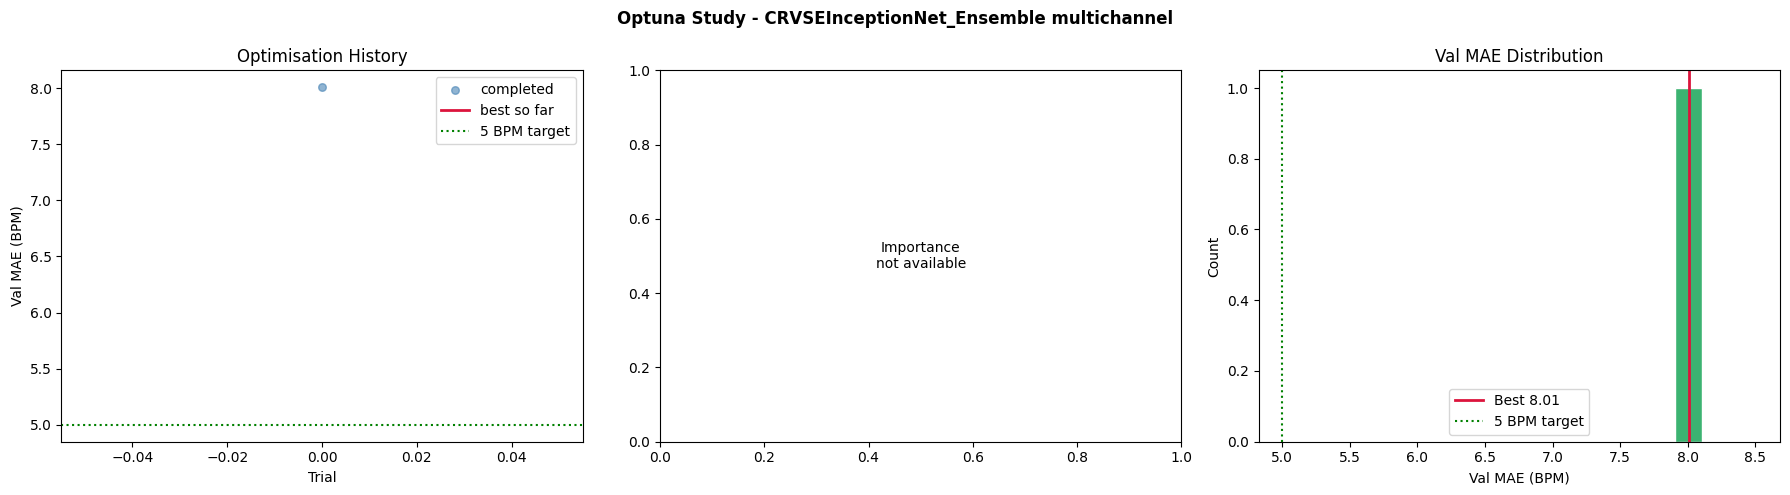

In [12]:
def plot_optuna_results(study: optuna.Study, model_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value  for t in trials]
    best_curve = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Optuna Study - {model_name}", fontweight="bold")

    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_curve, color="crimson", lw=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History"); axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        params, imps = zip(*list(importances.items())[:6])
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance"); axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Importance\nnot available", ha="center", va="center",
                     transform=axes[1].transAxes)

    axes[2].hist(val_maes, bins=max(5, len(val_maes)//2), color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", lw=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[2].set_xlabel("Val MAE (BPM)"); axes[2].set_ylabel("Count")
    axes[2].set_title("Val MAE Distribution"); axes[2].legend()

    plt.tight_layout(); plt.show()

plot_optuna_results(study, f"{MODEL_NAME} multichannel")


## 12. Final Training on Best Configuration

In [13]:
p = study.best_params
best_n_epochs = study.best_trial.last_step  # epochs the best trial actually ran

print("=" * 55)
print(f"Final retraining : {MODEL_NAME} ({INPUT_MODE})")
print(f"Best trial : #{study.best_trial.number}")
print(f"Best val MAE : {study.best_value:.2f} BPM")
print(f"Epochs to retrain: {best_n_epochs}")
print("=" * 55)
print("Best hyperparams:")
for k, v in p.items():
    print(f"  {k:<20} : {v}")

# FIX: was CRVSENet (NameError) — corrected to CRVSEInceptionNet1D
best_model = CRVSEInceptionNet1D(
    in_channels = IN_CHANNELS,
    branch_channels = p["branch_channels"],
    n_blocks = p["n_blocks"],
    dropout = p["dropout"],
    hr_min = HR_MIN,
    hr_max = HR_MAX,
).to(DEVICE)

# Train on train + val combined
full_ds = CRVSEDataset(all_samples, train_keys | val_keys, input_mode=INPUT_MODE)
full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
print(f"\nFull train set : {len(full_ds)} windows")

loss_fn = nn.HuberLoss(delta=p["huber_delta"])
optimizer = AdamW(best_model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
scheduler = CosineAnnealingLR(optimizer, T_max=best_n_epochs, eta_min=p["lr"] / 100)

epoch_bar = tqdm(range(1, best_n_epochs + 1), desc=f"Final Training {MODEL_NAME}", unit="epoch")
for epoch in epoch_bar:
    best_model.train()
    total_loss = 0.0
    for signals, labels in full_loader:
        signals, labels = signals.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(best_model(signals), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    epoch_bar.set_postfix({"loss": f"{total_loss / len(full_loader):.3f}"})

# Test evaluation 
test_ds = CRVSEDataset(all_samples, test_keys, input_mode=INPUT_MODE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

best_model.eval()
all_preds, all_labels = [], []
with torch.inference_mode():
    for signals, labels in test_loader:
        all_preds.extend(best_model(signals.to(DEVICE)).cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

all_subject_ids = [test_ds.items[i]["subject_key"] for i in range(len(test_ds))]
all_dataset_ids = [test_ds.items[i]["dataset"] for i in range(len(test_ds))]
preds_np = np.array(all_preds, dtype=np.float32)
labels_np = np.array(all_labels, dtype=np.float32)

full_evaluation(preds_np, labels_np, all_subject_ids, all_dataset_ids, model_name=f"{MODEL_NAME} - {INPUT_MODE}")

save_name = f"{MODEL_NAME}_{INPUT_MODE}_best.pt"
torch.save(best_model.state_dict(), save_name)
print(f"\nSaved -> {save_name}")

# Save best params as JSON for cross-notebook reference
params_file = f"{MODEL_NAME}_{INPUT_MODE}_best_params.json"
with open(params_file, "w") as f:
    json.dump({"input_mode": INPUT_MODE, "in_channels": IN_CHANNELS,
               "best_val_mae": study.best_value, "best_trial": study.best_trial.number,
               "best_n_epochs": best_n_epochs, **p}, f, indent=2)
print(f"Params -> {params_file}")


Final retraining : CRVSEInceptionNet_Ensemble (multichannel)
Best trial : #0
Best val MAE : 8.01 BPM
Epochs to retrain: 50
Best hyperparams:
  lr                   : 0.00023688639503640813
  weight_decay         : 0.0071144760093434225
  dropout              : 0.31959818254342154
  huber_delta          : 6.387926357773329
  branch_channels      : 128
  n_blocks             : 5
Dataset size: 15946 windows  (mode=multichannel)

Full train set : 15946 windows


Final Training CRVSEInceptionNet_Ensemble: 100%|██████████| 50/50 [44:08<00:00, 52.97s/epoch, loss=29.712]

Dataset size: 3106 windows  (mode=multichannel)



FULL EVALUATION  —  CRVSEInceptionNet_Ensemble - multichannel

Window-level (n=3106 windows):
MAE : 9.81 BPM
RMSE : 14.50 BPM
MAPE : 11.12 %
r : 0.6583  (p=0.0000)
R² : 0.2182
BA bias : -7.41 BPM
BA LoA : [-31.85, 17.02] BPM

|error| <  5 BPM : 41.6% of windows
|error| < 10 BPM : 65.0% of windows
|error| < 15 BPM : 79.7% of windows

Subject-level metrics (n=52 subjects):
MAE : 7.81 BPM
RMSE : 11.73 BPM
r : 0.8133
BA bias : -7.23 BPM
BA LoA : [-25.32, 10.87] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
ecg_fitness       278    28.85    34.49   0.3797
mcd_rppg         2094     7.39    10.03   0.8007
ubfc_phys         658    10.05    12.90   0.0712
ubfc_rppg          76     4.79     5.71   0.9664

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          370     6.20     8.59
normal low              1657     6.51     8.61
norma